In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("online_retail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)


Shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows:
5268


In [5]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2011-10-31 14:41:00,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [6]:
# Remove rows where CustomerID is missing
df = df.dropna(subset=['CustomerID'])

# Remove cancelled/returned transactions
df = df[df['Quantity'] > 0]

# Remove invalid prices
df = df[df['UnitPrice'] > 0]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create TotalAmount
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

print("Cleaned dataset shape:", df.shape)
df.head()

Cleaned dataset shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [7]:
print("Rows after cleaning:", len(df))
print("Unique Customers:", df['CustomerID'].nunique())
print("Unique Invoices:", df['InvoiceNo'].nunique())
print("Total Sales:", df['TotalAmount'].sum())

Rows after cleaning: 397884
Unique Customers: 4338
Unique Invoices: 18532
Total Sales: 8911407.904


In [8]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [9]:
print("Average Purchase Value:",
      df['TotalAmount'].sum() / df['InvoiceNo'].nunique())

print("Average Purchase Frequency:",
      rfm['Frequency'].mean())

print("Average Customer Lifetime Value:",
      rfm['Monetary'].mean())

print("\nRFM Statistics:")
print(rfm.describe())

Average Purchase Value: 480.8659563997409
Average Purchase Frequency: 4.272014753342554
Average Customer Lifetime Value: 2054.2664601198708

RFM Statistics:
           Recency    Frequency       Monetary
count  4338.000000  4338.000000    4338.000000
mean     92.536422     4.272015    2054.266460
std     100.014169     7.697998    8989.230441
min       1.000000     1.000000       3.750000
25%      18.000000     1.000000     307.415000
50%      51.000000     2.000000     674.485000
75%     142.000000     5.000000    1661.740000
max     374.000000   209.000000  280206.020000


In [10]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm[['Recency', 'Frequency', 'Monetary']]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)

rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334574,-0.425097,8.358668
12347.0,-0.905340,0.354417,0.250966
12348.0,-0.175360,-0.035340,-0.028596
12349.0,-0.735345,-0.425097,-0.033012
12350.0,2.174578,-0.425097,-0.191347


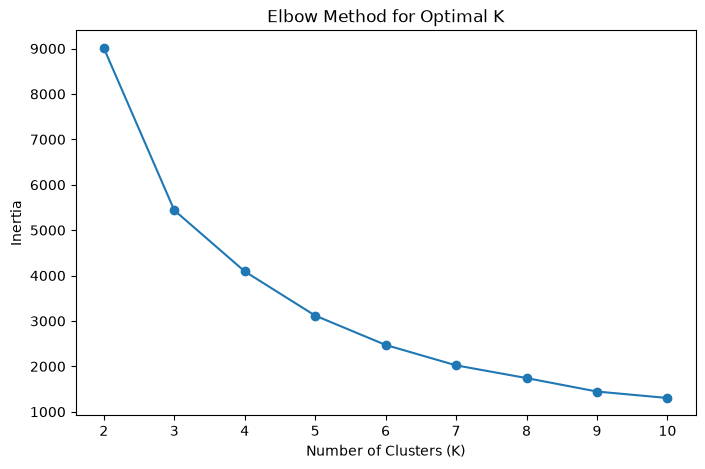

In [11]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [12]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [13]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

print(cluster_profile)

         Recency  Frequency   Monetary
Cluster                               
0          43.70       3.68    1359.05
1         248.08       1.55     480.62
2           7.38      82.54  127338.31
3          15.50      22.33   12709.09


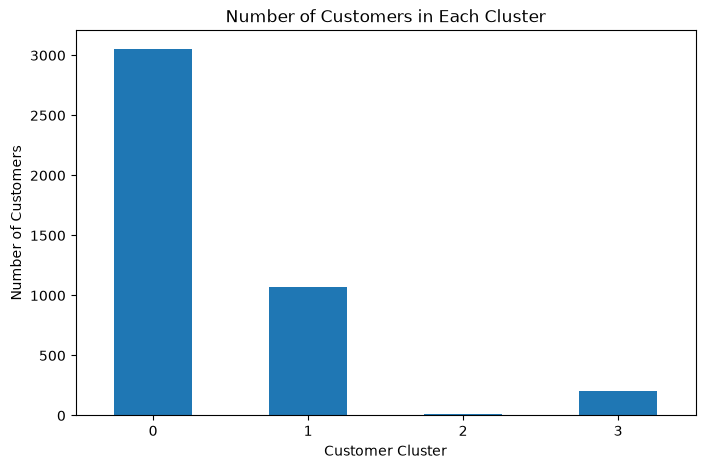

In [14]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar')

plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')
plt.xticks(rotation=0)
plt.show()

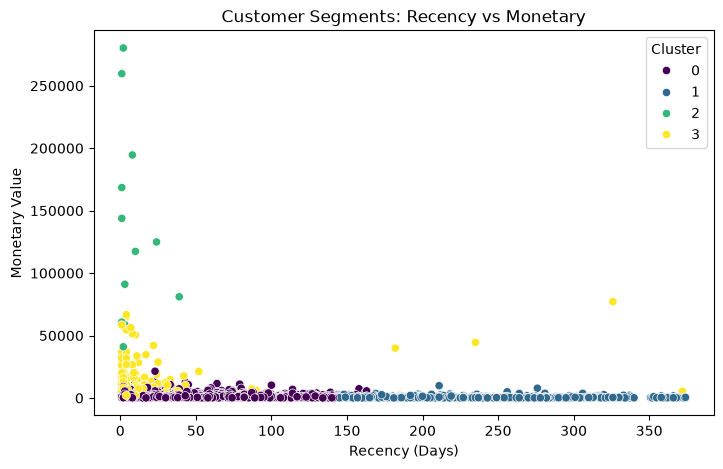

In [15]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.show()

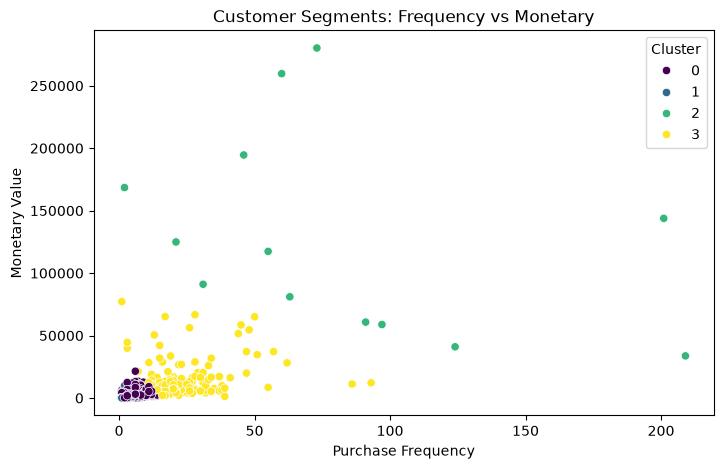

In [16]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis'
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.show()

In [17]:
cluster_profile = rfm.groupby('Cluster').agg(
    Customers=('Recency', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3054,43.70,3.68,1359.05
1,1067,248.08,1.55,480.62
2,13,7.38,82.54,127338.31
3,204,15.50,22.33,12709.09


In [18]:
print(cluster_profile)

         Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster                                                     
0             3054        43.70           3.68       1359.05
1             1067       248.08           1.55        480.62
2               13         7.38          82.54     127338.31
3              204        15.50          22.33      12709.09


In [19]:
cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,3054,43.70,3.68,1359.05
1,1067,248.08,1.55,480.62
2,13,7.38,82.54,127338.31
3,204,15.50,22.33,12709.09


In [20]:
cluster_names = {
    0: 'Champions',
    1: 'Loyal Customers',
    2: 'At-Risk Customers',
    3: 'Low-Value Customers'
}

rfm['Customer_Segment'] = rfm['Cluster'].map(cluster_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Customer_Segment
CustomerID,,,,,
12346.0,326,1,77183.60,3,Low-Value Customers
12347.0,2,7,4310.00,0,Champions
12348.0,75,4,1797.24,0,Champions
12349.0,19,1,1757.55,0,Champions
12350.0,310,1,334.40,1,Loyal Customers


In [21]:
segment_summary = rfm.groupby('Customer_Segment').agg(
    Customers=('Recency', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean')
).round(2)

segment_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Customer_Segment,,,,
At-Risk Customers,13,7.38,82.54,127338.31
Champions,3054,43.70,3.68,1359.05
Low-Value Customers,204,15.50,22.33,12709.09
Loyal Customers,1067,248.08,1.55,480.62


## Marketing Strategies by Customer Segment

### Champions
- Offer loyalty rewards and exclusive discounts.
- Promote premium and high-value products.
- Encourage referrals and repeat purchases.

### Loyal Customers
- Provide personalized recommendations.
- Offer loyalty points and bundle deals.
- Encourage higher purchase frequency.

### At-Risk Customers
- Send personalized re-engagement offers.
- Provide limited-time discounts.
- Use email campaigns to bring customers back.

### Low-Value Customers
- Offer introductory promotions.
- Use targeted low-cost campaigns.
- Encourage repeat purchases through small incentives.

## Conclusion

RFM analysis and K-Means clustering were used to segment customers based on their purchasing behaviour. Customers were grouped using Recency, Frequency, and Monetary values.

The identified customer segments can help businesses create targeted marketing campaigns, improve customer retention, increase repeat purchases, and focus resources on high-value customers.